In [186]:
import pandas as pd
import numpy as np

# ====================== #
# Models                 #
# ====================== #

from sklearn.cluster import (
    KMeans, 
    AgglomerativeClustering,
    DBSCAN,
    SpectralClustering
)

from sklearn.preprocessing import StandardScaler


# ====================== #
# Metrics                #
# ====================== #
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    classification_report,
    silhouette_score,
    confusion_matrix,
    adjusted_rand_score,
    normalized_mutual_info_score
)


from scipy.optimize import linear_sum_assignment

import matplotlib.pyplot as plt

In [187]:
RANDOM_STATE = 777

In [188]:
wine_df = pd.read_csv(
    filepath_or_buffer="wine-clustering.csv"
)

columns_for_original = ["class"]
columns_for_original.extend(wine_df.columns)

original_df = pd.read_csv(
    filepath_or_buffer="from_original_source/wine.csv",
    names=columns_for_original
)

In [189]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [190]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_Acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Ash_Alcanity          178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_Phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_Phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_Intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280                 178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


Due to the fact that I have an access to the original dataset with `class` label, I will be able to check my results directly with correctly labeled data. 

In [191]:
def check_identity(df1: pd.DataFrame, df2: pd.DataFrame) -> bool:
    return df1.equals(df2)

check_identity(df1=wine_df, df2=original_df.drop(columns="class"))

True

In [192]:
X = wine_df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### K-means Clustering

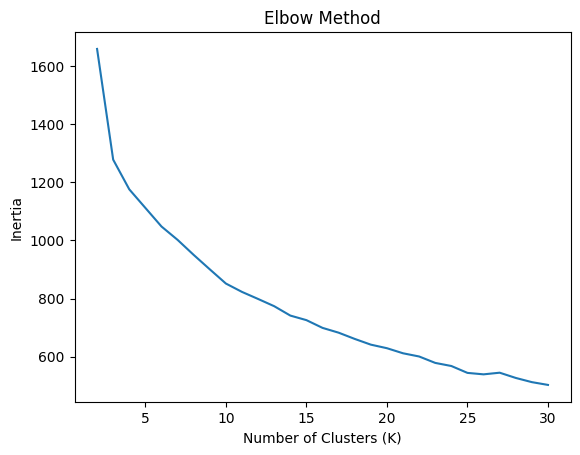

In [193]:
inertia = []

for k in range(2, 31):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 31), inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [194]:
k_silhouette = dict()

for k in range(2, 31):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = np.round(silhouette_score(X_scaled, labels), 4)
    k_silhouette[k] = score

sorted(k_silhouette.items(), key=lambda expression: expression[1], reverse=True)

[(3, np.float64(0.2849)),
 (2, np.float64(0.2683)),
 (4, np.float64(0.2517)),
 (5, np.float64(0.2094)),
 (6, np.float64(0.186)),
 (11, np.float64(0.1586)),
 (25, np.float64(0.155)),
 (10, np.float64(0.1468)),
 (14, np.float64(0.1443)),
 (29, np.float64(0.1436)),
 (7, np.float64(0.1427)),
 (12, np.float64(0.1407)),
 (26, np.float64(0.1404)),
 (19, np.float64(0.1397)),
 (15, np.float64(0.1385)),
 (18, np.float64(0.1385)),
 (24, np.float64(0.1385)),
 (23, np.float64(0.1368)),
 (13, np.float64(0.1354)),
 (21, np.float64(0.1352)),
 (16, np.float64(0.135)),
 (30, np.float64(0.1337)),
 (17, np.float64(0.1323)),
 (28, np.float64(0.1322)),
 (20, np.float64(0.1304)),
 (8, np.float64(0.1298)),
 (22, np.float64(0.1292)),
 (9, np.float64(0.1289)),
 (27, np.float64(0.1279))]

In [195]:
kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300
)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",777
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [196]:
records_table = pd.DataFrame()
def add_to_records_table(
    records_table: pd.DataFrame, 
    model_name: str,
    model_accuracy: np.float64 = None,
    adjusted_rand_score: np.float64 = None,
    normalized_mutual_info_score: np.float64 = None
    ) -> None:

    records_table.loc[len(records_table), "model_name"] = model_name
    records_table.loc[len(records_table) - 1, "model_accuracy"] = model_accuracy
    records_table.loc[len(records_table) - 1, "adjusted_rand_score"] = adjusted_rand_score
    records_table.loc[len(records_table) - 1, "normalized_mutual_info_score"] = normalized_mutual_info_score
    

In [197]:
records_table

""


#### Checking Accuracy

In [198]:
predicted_clusters = kmeans.predict(X_scaled)
actual_clusters = original_df["class"]

In [199]:
def hungarian_algorithm(actual_clusters, predicted_clusters):
    cm = confusion_matrix(actual_clusters, predicted_clusters)
    row_ind, col_ind = linear_sum_assignment(-cm)

    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    mapped_predictions = np.array([mapping[label] for label in predicted_clusters])

    return mapped_predictions

In [200]:
mapped_predictions = hungarian_algorithm(
    actual_clusters=actual_clusters,
    predicted_clusters=predicted_clusters
)

In [201]:
mapped_predictions

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3])

In [202]:
np.array(actual_clusters.to_list())

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3])

In [203]:
kmeans_accuracy_score = np.round(
    accuracy_score(actual_clusters, mapped_predictions), 4
)
kmeans_f1_score = f1_score(actual_clusters, mapped_predictions, average="weighted")
kmeans_precision_score = precision_score(actual_clusters, mapped_predictions, average="weighted")
kmeans_recall_score = recall_score(actual_clusters, mapped_predictions, average="weighted")

kmeans_adjusted_rand_score = np.round(
    adjusted_rand_score(actual_clusters, predicted_clusters), 4
)

kmeans_normalized_mutual_info_score = np.round(
    normalized_mutual_info_score(actual_clusters, predicted_clusters), 4
)

In [204]:
add_to_records_table(
    records_table=records_table,
    model_name="K-means",
    model_accuracy=kmeans_accuracy_score,
    adjusted_rand_score=kmeans_adjusted_rand_score,
    normalized_mutual_info_score=kmeans_normalized_mutual_info_score
)

In [205]:
records_table

,model_name,model_accuracy,adjusted_rand_score,normalized_mutual_info_score
0,K-means,0.9663,0.8975,0.8759


### Hierarchical (Agglomerative) Clustering

In [206]:
def grid_search(clusters_size: int, original_df: pd.DataFrame) -> dict:
    actual_clusters = original_df["class"]
    result = dict()

    for n_clusters in range(2, clusters_size + 1):
        for linkage in ['ward', 'complete', 'average', 'single']:
            print(f"Testing for pair: ({n_clusters}, {linkage})")

            agglomerative_clustering = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage
            )

            predicted_clusters = agglomerative_clustering.fit_predict(X_scaled)
            mapped_predictions = hungarian_algorithm(
                actual_clusters=actual_clusters,
                predicted_clusters=predicted_clusters
            )

            agglomerative_clustering_adjusted_rand_score = np.round(
                adjusted_rand_score(actual_clusters, predicted_clusters), 4
            )

            agglomerative_clustering_normalized_mutual_info_score = np.round(
                normalized_mutual_info_score(actual_clusters, predicted_clusters), 4
            )

            agglomerative_clustering_silhouette_score = np.round(
                silhouette_score(X_scaled, predicted_clusters), 4
            )

            agglomerative_clustering_accuracy = np.round(
                accuracy_score(actual_clusters, mapped_predictions), 4
            )

            result[(n_clusters, linkage)] = [
                agglomerative_clustering_adjusted_rand_score,
                agglomerative_clustering_normalized_mutual_info_score,
                agglomerative_clustering_silhouette_score,
                agglomerative_clustering_accuracy,
            ]

    return result

In [207]:
result = grid_search(clusters_size=5, original_df=original_df)

Testing for pair: (2, ward)
Testing for pair: (2, complete)
Testing for pair: (2, average)
Testing for pair: (2, single)
Testing for pair: (3, ward)
Testing for pair: (3, complete)
Testing for pair: (3, average)
Testing for pair: (3, single)
Testing for pair: (4, ward)
Testing for pair: (4, complete)
Testing for pair: (4, average)
Testing for pair: (4, single)
Testing for pair: (5, ward)
Testing for pair: (5, complete)
Testing for pair: (5, average)
Testing for pair: (5, single)


In [208]:
sorted(result.items(), key=lambda expression: expression[1][2], reverse=True)[0]

((3, 'ward'),
 [np.float64(0.7899),
  np.float64(0.7865),
  np.float64(0.2774),
  np.float64(0.927)])

Best hyperparameters are 3 for `n_clusters` and `ward` for linkage

In [209]:
agglomerative_clustering = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

predicted_clusters = agglomerative_clustering.fit_predict(X_scaled)
mapped_predictions = hungarian_algorithm(
    actual_clusters=actual_clusters,
    predicted_clusters=predicted_clusters
)

agglomerative_clustering_adjusted_rand_score = np.round(
    adjusted_rand_score(actual_clusters, predicted_clusters), 4
)

agglomerative_clustering_normalized_mutual_info_score = np.round(
    normalized_mutual_info_score(actual_clusters, predicted_clusters), 4
)

agglomerative_clustering_silhouette_score = np.round(
    silhouette_score(X_scaled, predicted_clusters), 4
)

agglomerative_clustering_accuracy = np.round(
    accuracy_score(actual_clusters, mapped_predictions), 4
)

In [210]:
add_to_records_table(
    records_table=records_table,
    model_name="Agglomerative Clustering",
    model_accuracy=agglomerative_clustering_accuracy,
    adjusted_rand_score=agglomerative_clustering_adjusted_rand_score,
    normalized_mutual_info_score=agglomerative_clustering_normalized_mutual_info_score
)

In [211]:
records_table

,model_name,model_accuracy,adjusted_rand_score,normalized_mutual_info_score
0,K-means,0.9663,0.8975,0.8759
1,Agglomerative Clustering,0.9270,0.7899,0.7865


### Spectral Clustering

In [212]:
spectral = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    random_state=RANDOM_STATE
)

predicted_clusters = spectral.fit_predict(X_scaled)
actual_clusters = original_df["class"]

In [213]:
print("Adjusted Rand Index:", adjusted_rand_score(actual_clusters, predicted_clusters))
print("Normalized Mutual Info:", normalized_mutual_info_score(actual_clusters, predicted_clusters))

Adjusted Rand Index: 0.8803997758776985
Normalized Mutual Info: 0.8609456714542119


In [214]:
spectral_rand_score = np.round(adjusted_rand_score(
    labels_true=actual_clusters,
    labels_pred=predicted_clusters
), 4)

spectral_mutual_info = np.round(normalized_mutual_info_score(
    labels_true=actual_clusters,
    labels_pred=predicted_clusters
), 4)

mapped_predictions = hungarian_algorithm(
    actual_clusters=actual_clusters,
    predicted_clusters=predicted_clusters
)

spectral_clustering_accuracy = np.round(
    accuracy_score(actual_clusters, mapped_predictions), 4
)

In [215]:
add_to_records_table(
    records_table=records_table,
    model_name="Specteal Clustering",
    model_accuracy=spectral_clustering_accuracy,
    normalized_mutual_info_score=spectral_mutual_info,
    adjusted_rand_score=spectral_rand_score
)

In [216]:
records_table

,model_name,model_accuracy,adjusted_rand_score,normalized_mutual_info_score
0,K-means,0.9663,0.8975,0.8759
1,Agglomerative Clustering,0.9270,0.7899,0.7865
2,Specteal Clustering,0.9607,0.8804,0.8609


#### Spectral Clustering Grid Search of Hyperparameters

In [217]:
def spectral_clustering_grid_search(clusters_size: int, original_df: pd.DataFrame) -> dict:
    actual_clusters = original_df["class"]
    result = dict()

    for n_clusters in range(2, clusters_size + 1):
        for affinity in ["rbf", "nearest_neighbors"]:
            print(f"Testing for pair: ({n_clusters}, {affinity})")

            spectral_clustering = SpectralClustering(
                n_clusters=n_clusters,
                affinity=affinity,
                random_state=RANDOM_STATE
            )

            predicted_clusters = spectral_clustering.fit_predict(X_scaled)
            mapped_predictions = hungarian_algorithm(
                actual_clusters=actual_clusters,
                predicted_clusters=predicted_clusters
            )

            spectral_clustering_adjusted_rand_score = np.round(
                adjusted_rand_score(actual_clusters, predicted_clusters), 4
            )

            spectral_clustering_normalized_mutual_info_score = np.round(
                normalized_mutual_info_score(actual_clusters, predicted_clusters), 4
            )

            spectral_clustering_silhouette_score = np.round(
                silhouette_score(X_scaled, predicted_clusters), 4
            )

            spectral_clustering_accuracy = np.round(
                accuracy_score(actual_clusters, mapped_predictions), 4
            )

            result[(n_clusters, affinity)] = [
                spectral_clustering_adjusted_rand_score,
                spectral_clustering_normalized_mutual_info_score,
                spectral_clustering_silhouette_score,
                spectral_clustering_accuracy,
            ]

    return result

In [218]:
results = spectral_clustering_grid_search(
    clusters_size=10,
    original_df=original_df
)

Testing for pair: (2, rbf)
Testing for pair: (2, nearest_neighbors)
Testing for pair: (3, rbf)
Testing for pair: (3, nearest_neighbors)
Testing for pair: (4, rbf)
Testing for pair: (4, nearest_neighbors)
Testing for pair: (5, rbf)
Testing for pair: (5, nearest_neighbors)
Testing for pair: (6, rbf)
Testing for pair: (6, nearest_neighbors)
Testing for pair: (7, rbf)
Testing for pair: (7, nearest_neighbors)
Testing for pair: (8, rbf)
Testing for pair: (8, nearest_neighbors)
Testing for pair: (9, rbf)
Testing for pair: (9, nearest_neighbors)
Testing for pair: (10, rbf)
Testing for pair: (10, nearest_neighbors)


In [219]:
sorted(results.items(), key=lambda expression: expression[1][2], reverse=True)[0]

((3, 'nearest_neighbors'),
 [np.float64(0.8804),
  np.float64(0.8609),
  np.float64(0.2828),
  np.float64(0.9607)])

In [220]:
sorted(results.items(), key=lambda expression: expression[1][3], reverse=True)[0]

((3, 'nearest_neighbors'),
 [np.float64(0.8804),
  np.float64(0.8609),
  np.float64(0.2828),
  np.float64(0.9607)])

In [221]:
spectral_clustering = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors"
)

predicted_clusters = spectral_clustering.fit_predict(X_scaled)
mapped_predictions = hungarian_algorithm(
    actual_clusters=actual_clusters,
    predicted_clusters=predicted_clusters
)

spectral_clustering_adjusted_rand_score = np.round(
    adjusted_rand_score(actual_clusters, predicted_clusters), 4
)

spectral_clustering_normalized_mutual_info_score = np.round(
    normalized_mutual_info_score(actual_clusters, predicted_clusters), 4
)

spectral_clustering_silhouette_score = np.round(
    silhouette_score(X_scaled, predicted_clusters), 4
)

spectral_clustering_accuracy = np.round(
    accuracy_score(actual_clusters, mapped_predictions), 4
)

In [222]:
add_to_records_table(
    records_table=records_table,
    model_name="Spectral Clustering - Grid Search",
    model_accuracy=spectral_clustering_accuracy,
    adjusted_rand_score=spectral_clustering_adjusted_rand_score,
    normalized_mutual_info_score=spectral_clustering_normalized_mutual_info_score
)

In [223]:
records_table

,model_name,model_accuracy,adjusted_rand_score,normalized_mutual_info_score
0,K-means,0.9663,0.8975,0.8759
1,Agglomerative Clustering,0.9270,0.7899,0.7865
2,Specteal Clustering,0.9607,0.8804,0.8609
3,Spectral Clustering - Grid Search,0.9607,0.8804,0.8609
